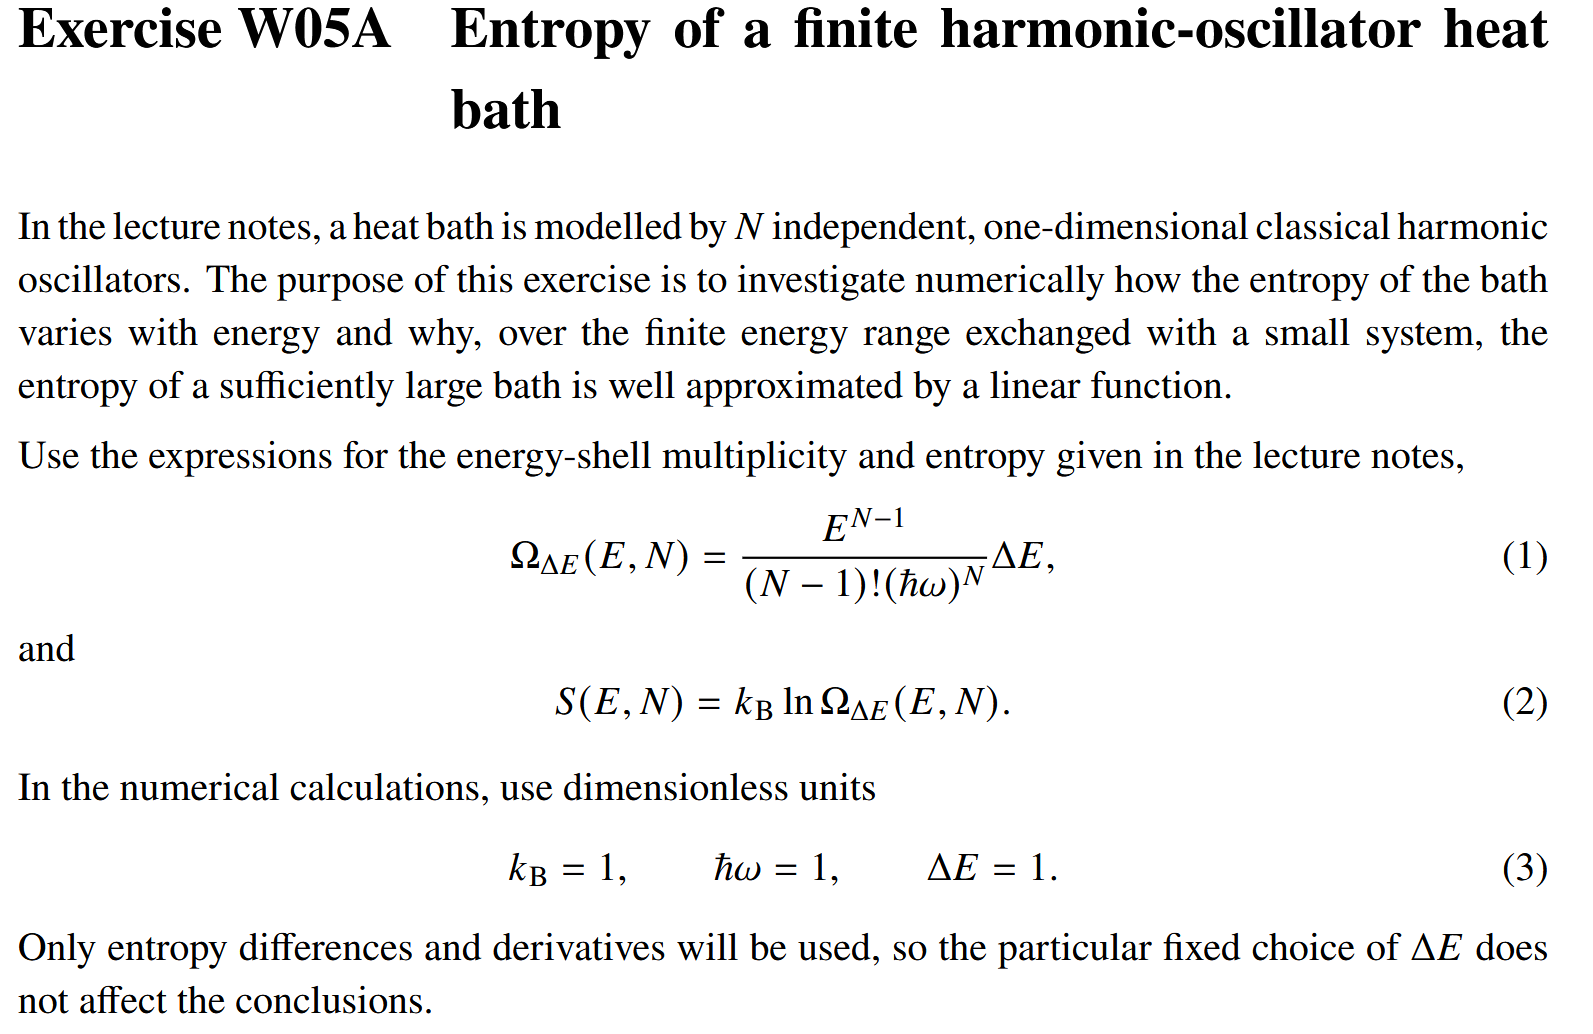
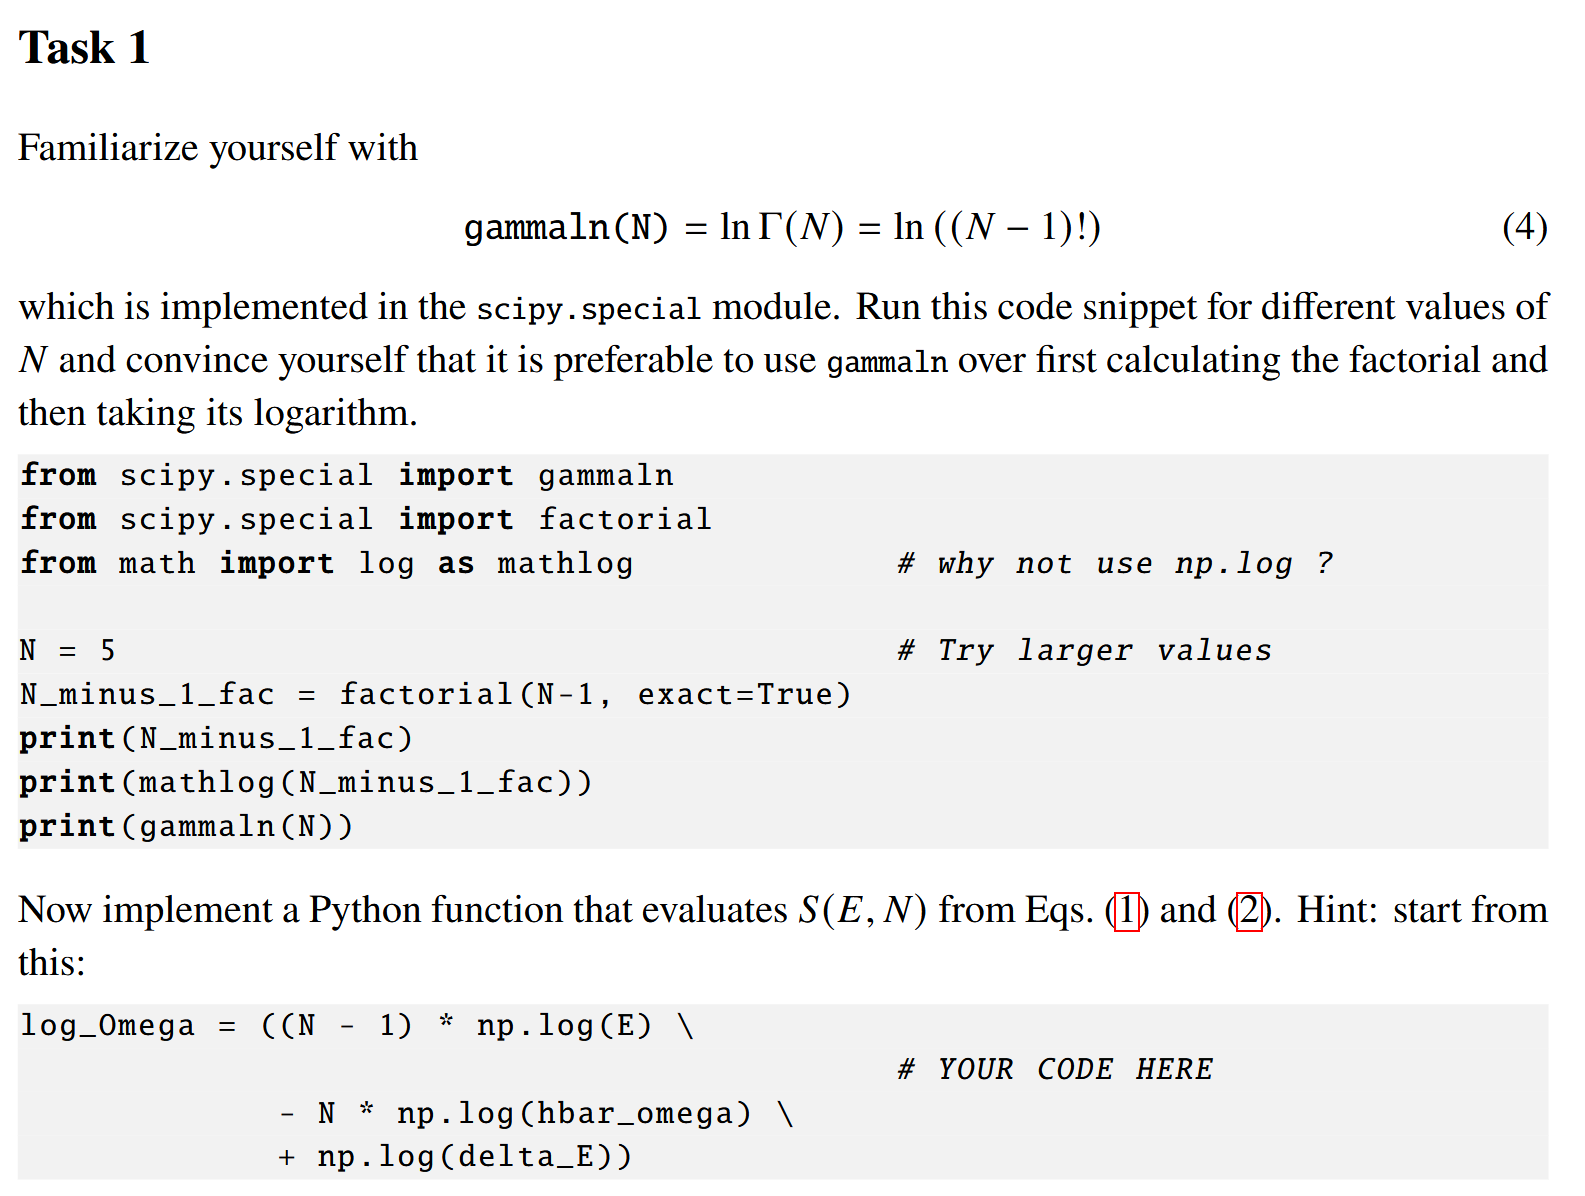

In [ ]:
from scipy.special import gammaln
from scipy.special import factorial
from math import log as mathlog

N = 10_000
N_minus_1_fac = factorial(N-1, exact=True)


In [7]:
print(N_minus_1_fac)
print(mathlog(N_minus_1_fac))

ValueError: Exceeds the limit (4300 digits) for integer string conversion; use sys.set_int_max_str_digits() to increase the limit

In [5]:
print(gammaln(N))

1051287.7089736569


In [16]:
import numpy as np
def S(E, N, kb=1, hω=1, dE=1): 
    return kb * ((N-1) * np.log(E) - gammaln(N) - N*np.log(hω) + np.log(dE))

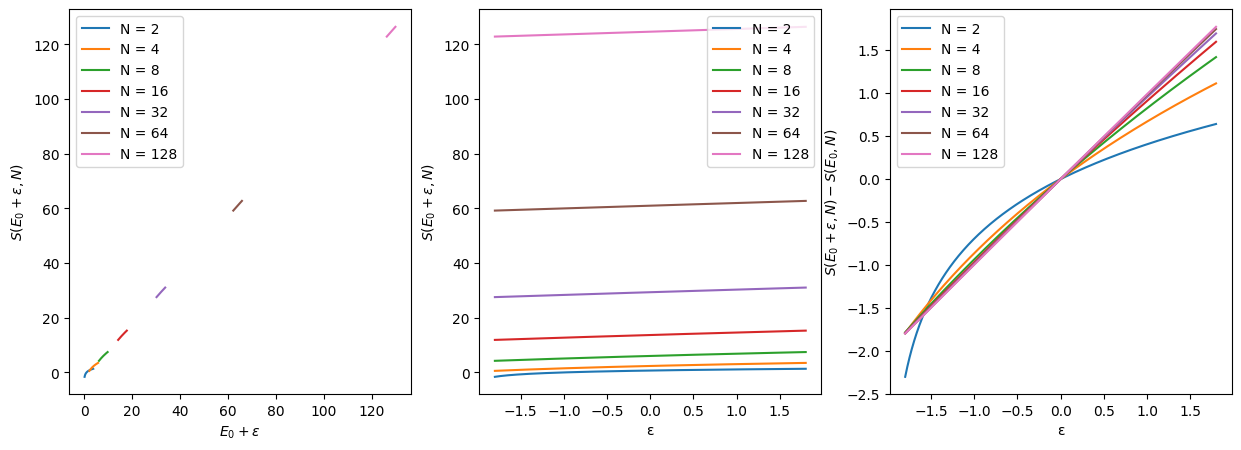

In [20]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(1,3, figsize=(15, 5))

u = 1

ε = np.linspace(-1.8, 1.8, 1000)

for N in [2, 4, 8, 16, 32, 64, 128]: # 
    E0 = N * u
    Ee = E0+ε
    ax[0].plot(Ee, S(Ee, N), label=f'N = {N}')
    ax[1].plot(ε, S(Ee, N), label=f'N = {N}')
    ax[2].plot(ε, S(E0+ε, N)-S(E0, N), label=f'N = {N}')

ax[0].set_xlabel(r'$E_0 + ε$')
ax[0].set_ylabel(r'$S(E_0 + ε, N)$')
ax[0].legend()
ax[1].set_xlabel('ε')
ax[1].set_ylabel(r'$S(E_0 + ε, N)$')
ax[1].legend()
ax[2].set_xlabel('ε')
ax[2].set_ylabel(r'$S(E_0 + ε, N) - S(E_0, N)$')
ax[2].legend()

### 1. Show the actual energy where it can be hard to see the difference 
### 2. Shows entropy only around the small energy interval, so we can see that N=128 actually has a higher entropy 
### 3. This shows the temperature of the baths since 1/T = dS/dE
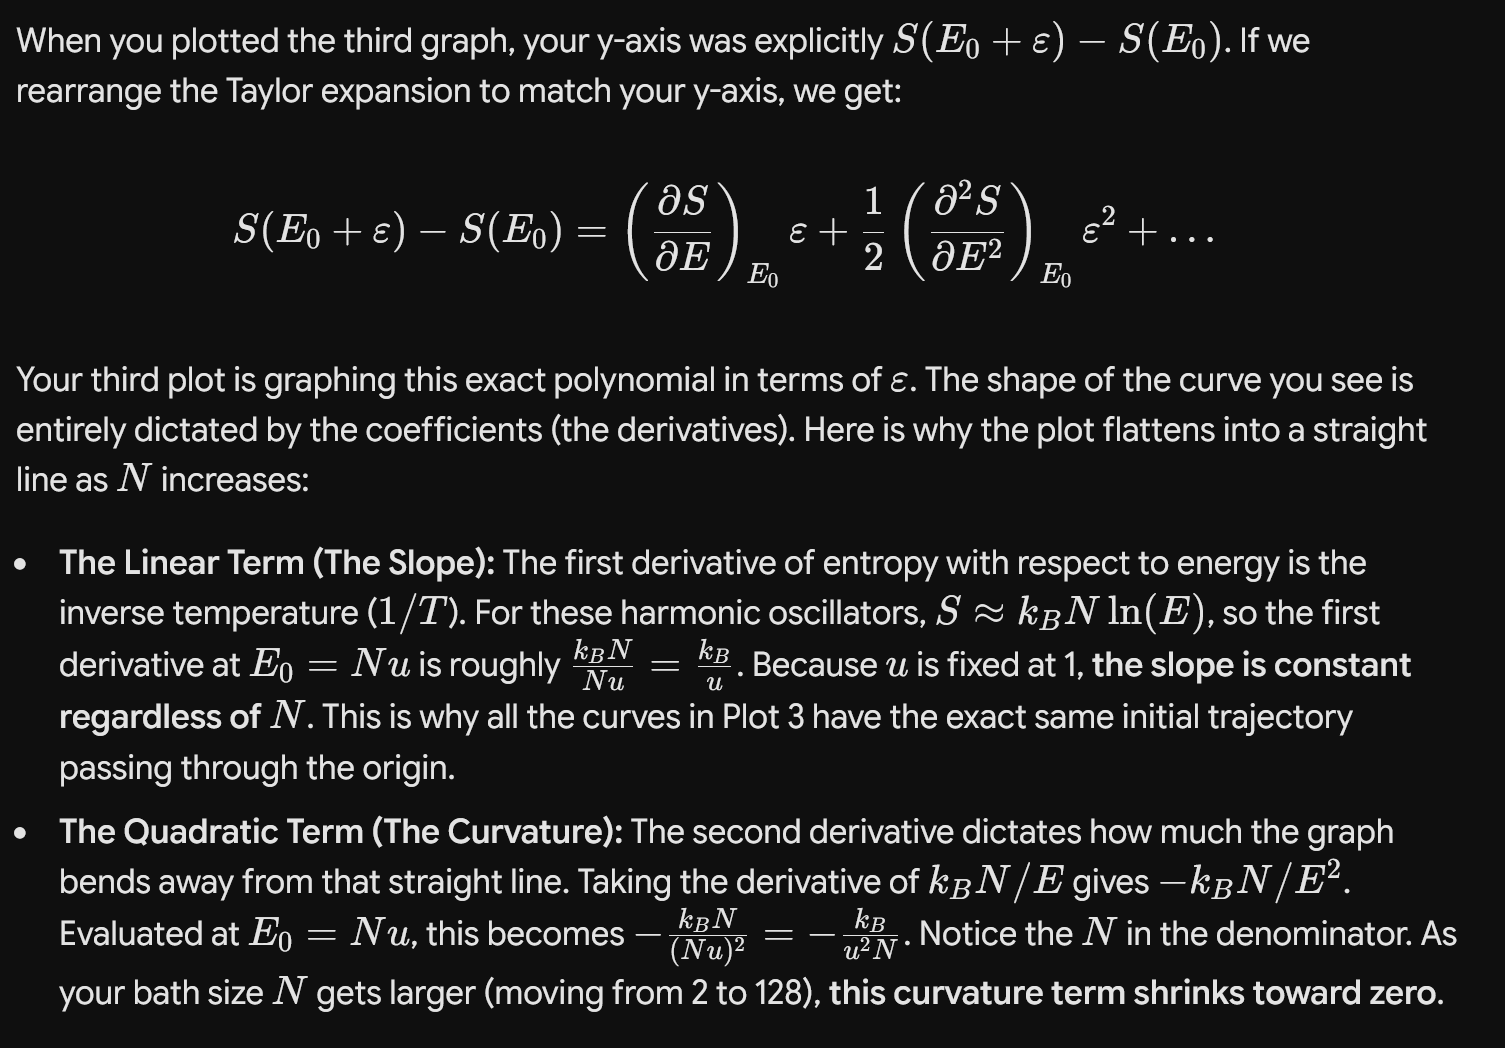

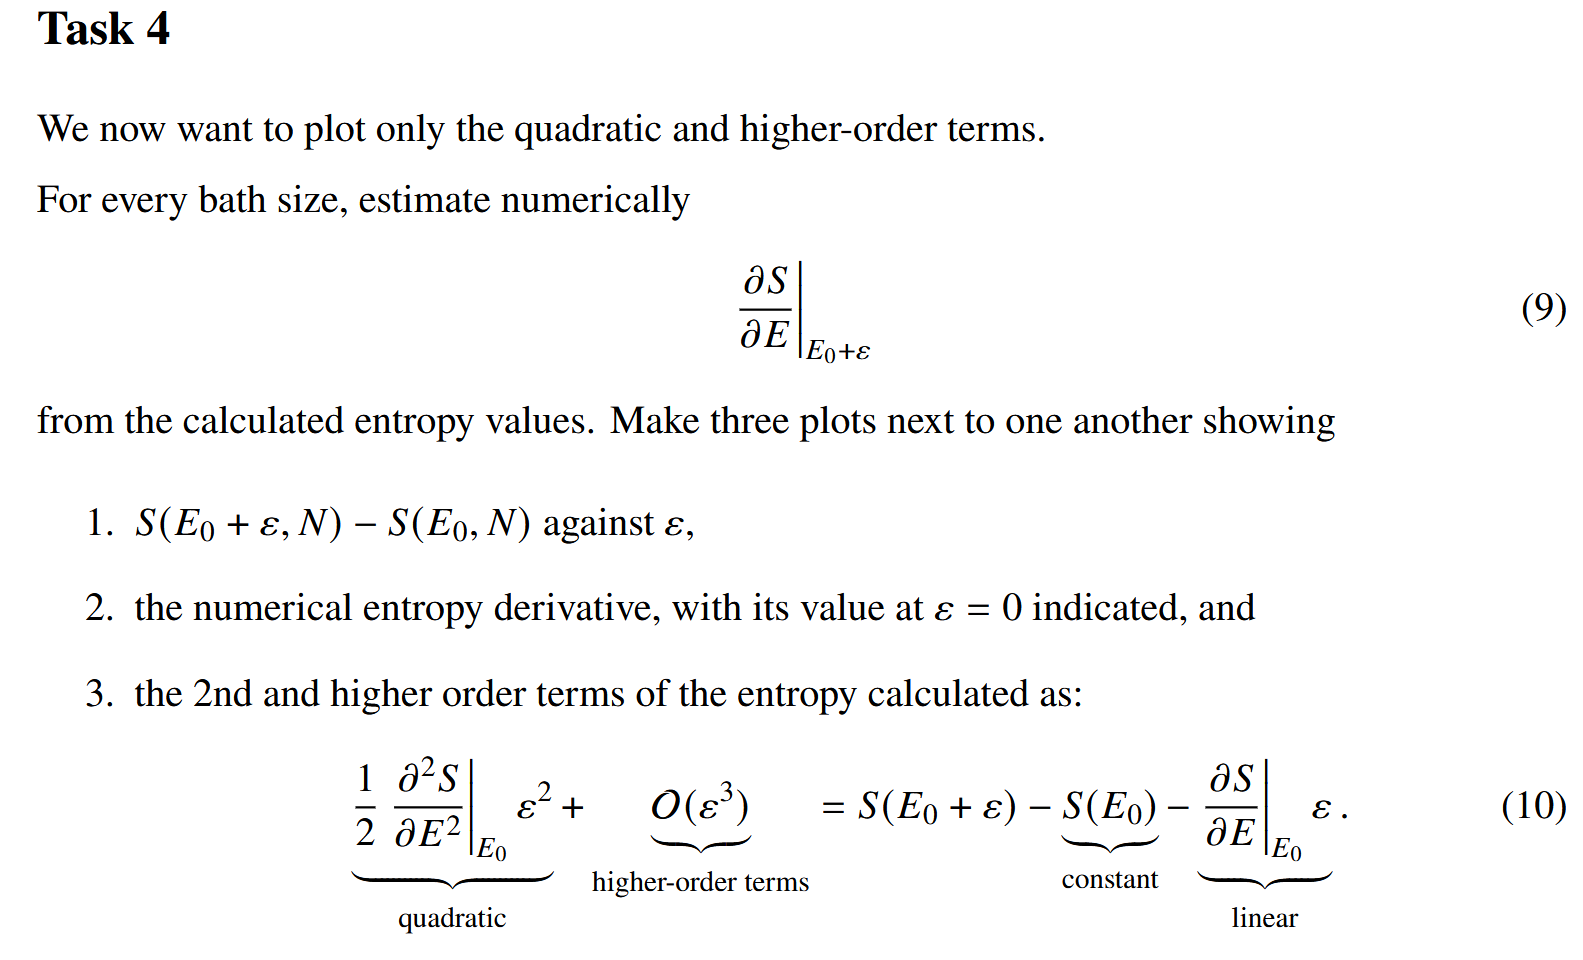

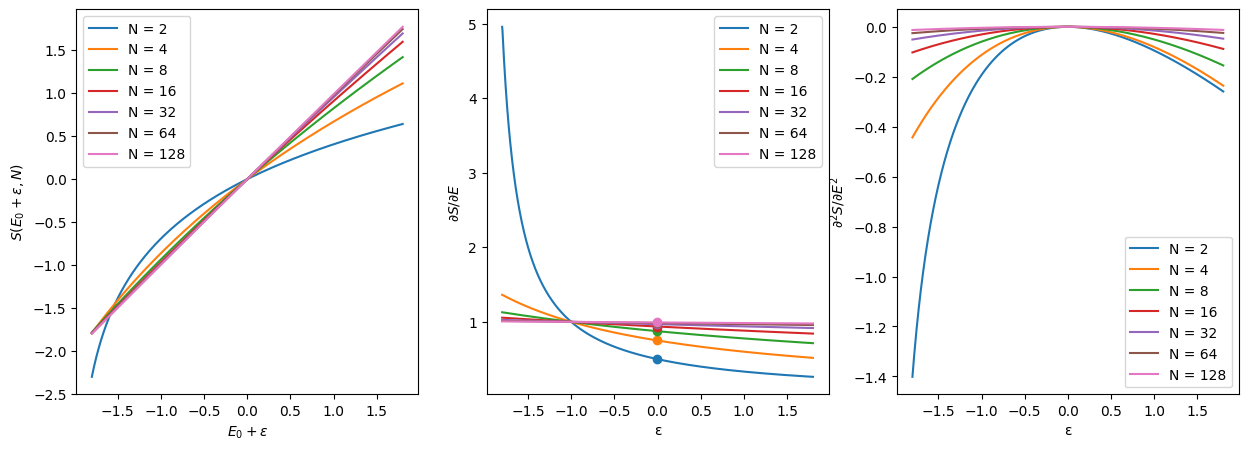

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

u = 1
ε = np.linspace(-1.8, 1.8, 1000)

for N in [2, 4, 8, 16, 32, 64, 128]: 
    E0 = N * u
    dS = S(E0+ε, N) - S(E0, N)
    ax[0].plot(ε, dS, label=f'N = {N}')

    grad = np.gradient(dS, ε)
    p = ax[1].plot(ε, grad, label=f'N = {N}')
    c = p[0].get_color()

    idx = np.argmin(abs(ε))
    ax[1].plot(ε[idx], grad[idx], 'o', color=c)

    quad = dS - grad[idx]*ε
    ax[2].plot(ε, quad, label=f'N = {N}')


ax[0].set_xlabel(r'$E_0 + ε$')
ax[0].set_ylabel(r'$S(E_0 + ε, N)$')
ax[0].legend()
ax[1].set_xlabel('ε')
ax[1].set_ylabel(r'$\partial S / \partial E$')
ax[1].legend()
ax[2].set_xlabel('ε')
ax[2].set_ylabel(r'$\partial^2 S / \partial E^2$')
ax[2].legend()
    

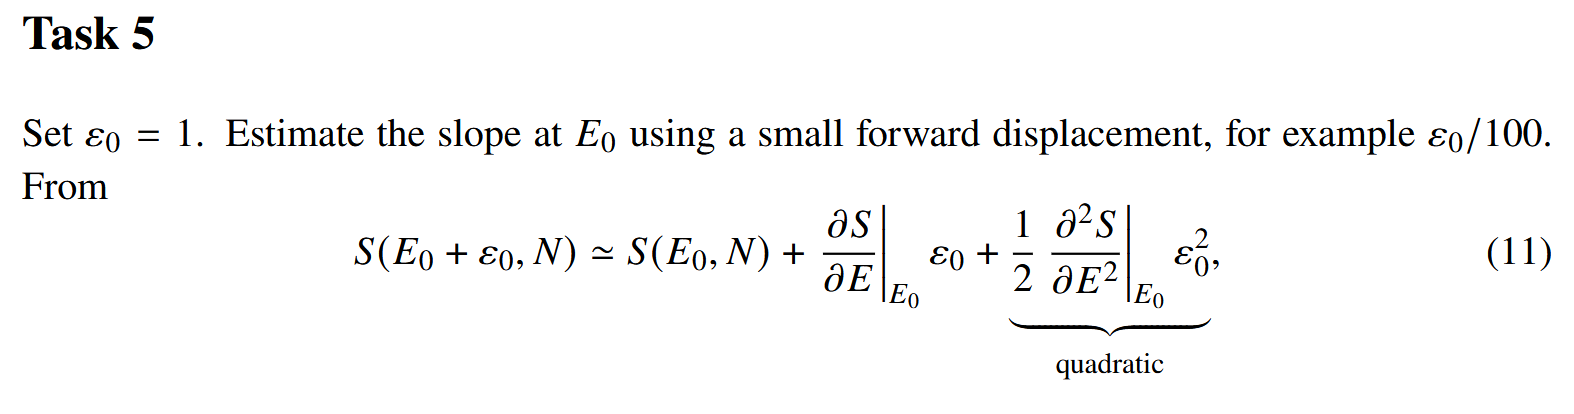
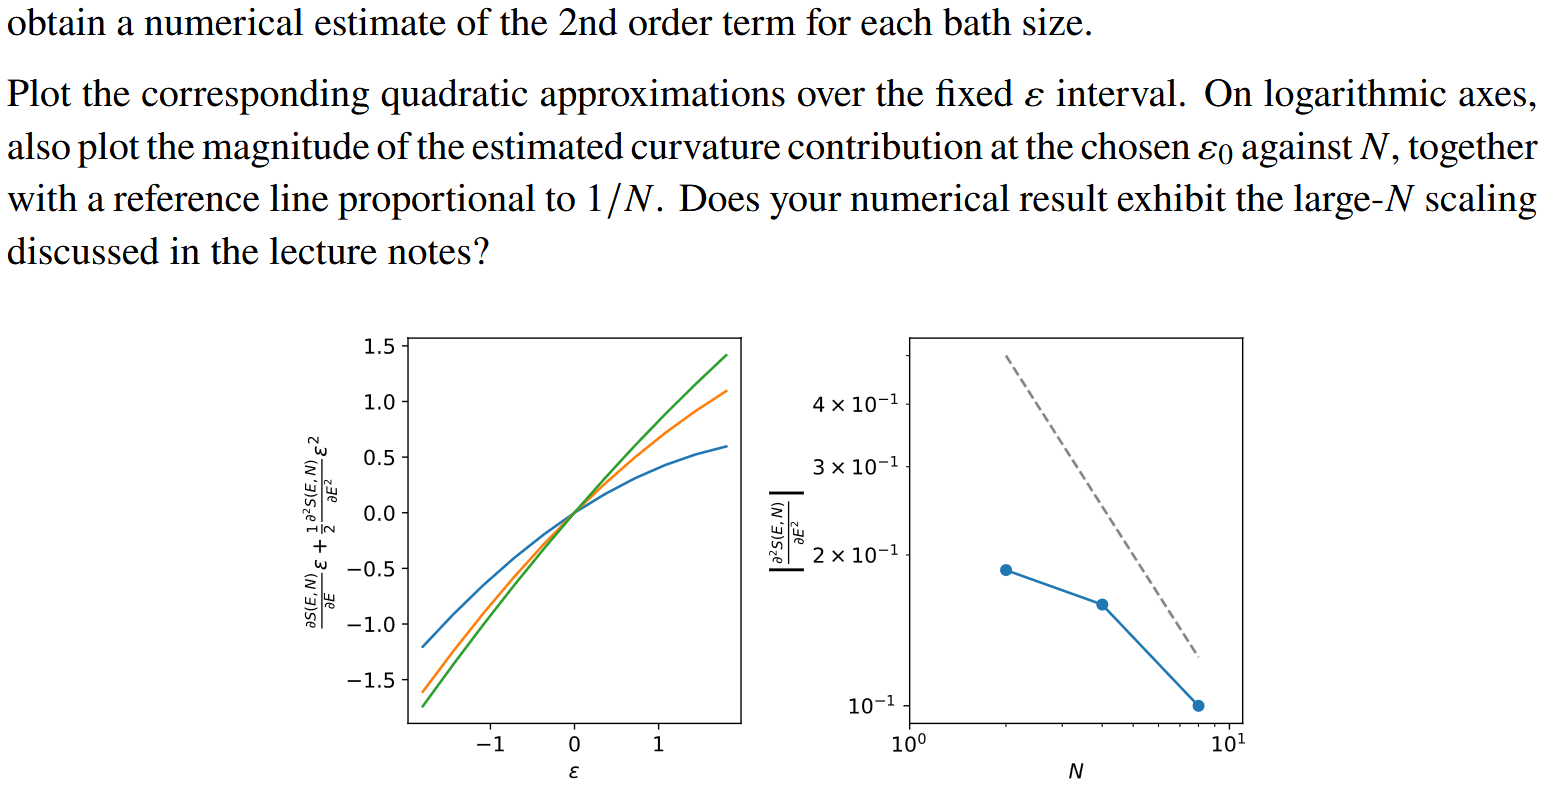

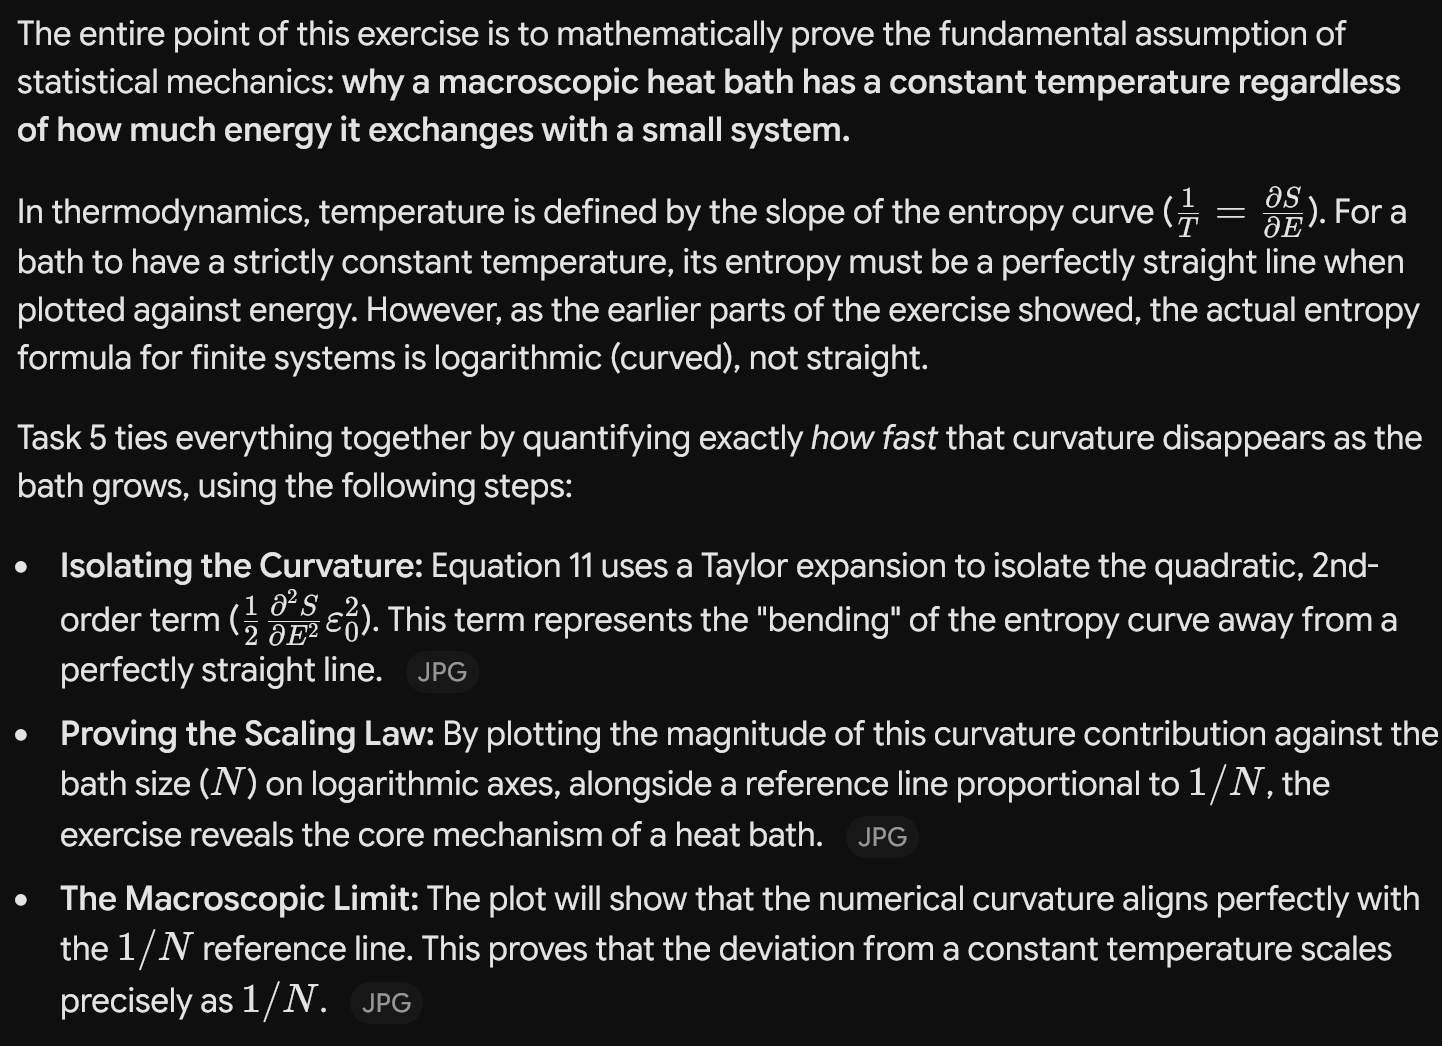

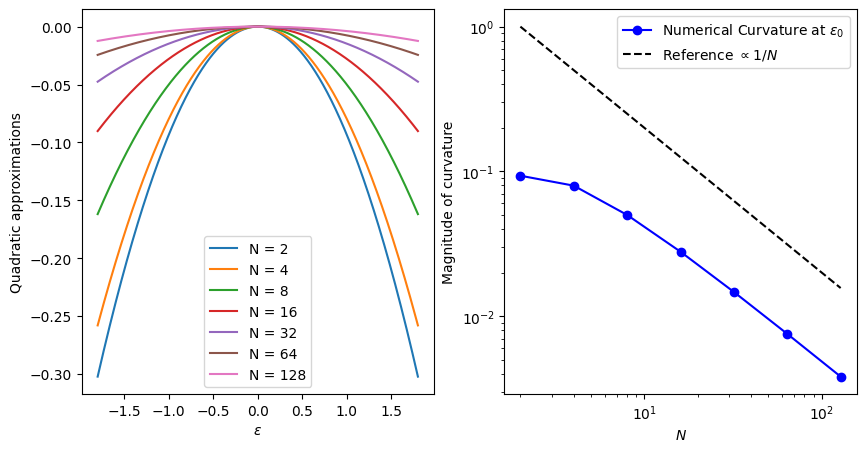

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

u = 1
ε = np.linspace(-1.8, 1.8, 1000)
N_vals = np.array([2, 4, 8, 16, 32, 64, 128])

curv = []

for N in N_vals: 
    E0 = N * u
    ep0 = 1.0
    disp = ep0/100

    slope = (S(E0 + disp, N) - S(E0, N)) / disp
    
    dS_ε0 = S(E0 + ep0, N) - S(E0, N)

    quad = dS_ε0 - slope * ep0
    curv.append(np.abs(quad))

    quad_approx = quad * (ε / ep0)**2
    ax[0].plot(ε, quad_approx, label=f'N = {N}')

ax[0].set_xlabel(r'$\epsilon$')
ax[0].set_ylabel('Quadratic approximations')
ax[0].legend()

# Plot 2: Magnitude of estimated curvature against N on logarithmic axes
ax[1].loglog(N_vals, curv, 'bo-', label=r'Numerical Curvature at $\epsilon_0$')

# Reference line proportional to 1/N (anchored to the first point for visual comparison)
ref_line = (N_vals[0] / N_vals)
ax[1].loglog(N_vals, ref_line, 'k--', label=r'Reference $\propto 1/N$')

ax[1].set_xlabel(r'$N$')
ax[1].set_ylabel('Magnitude of curvature')
ax[1].legend()


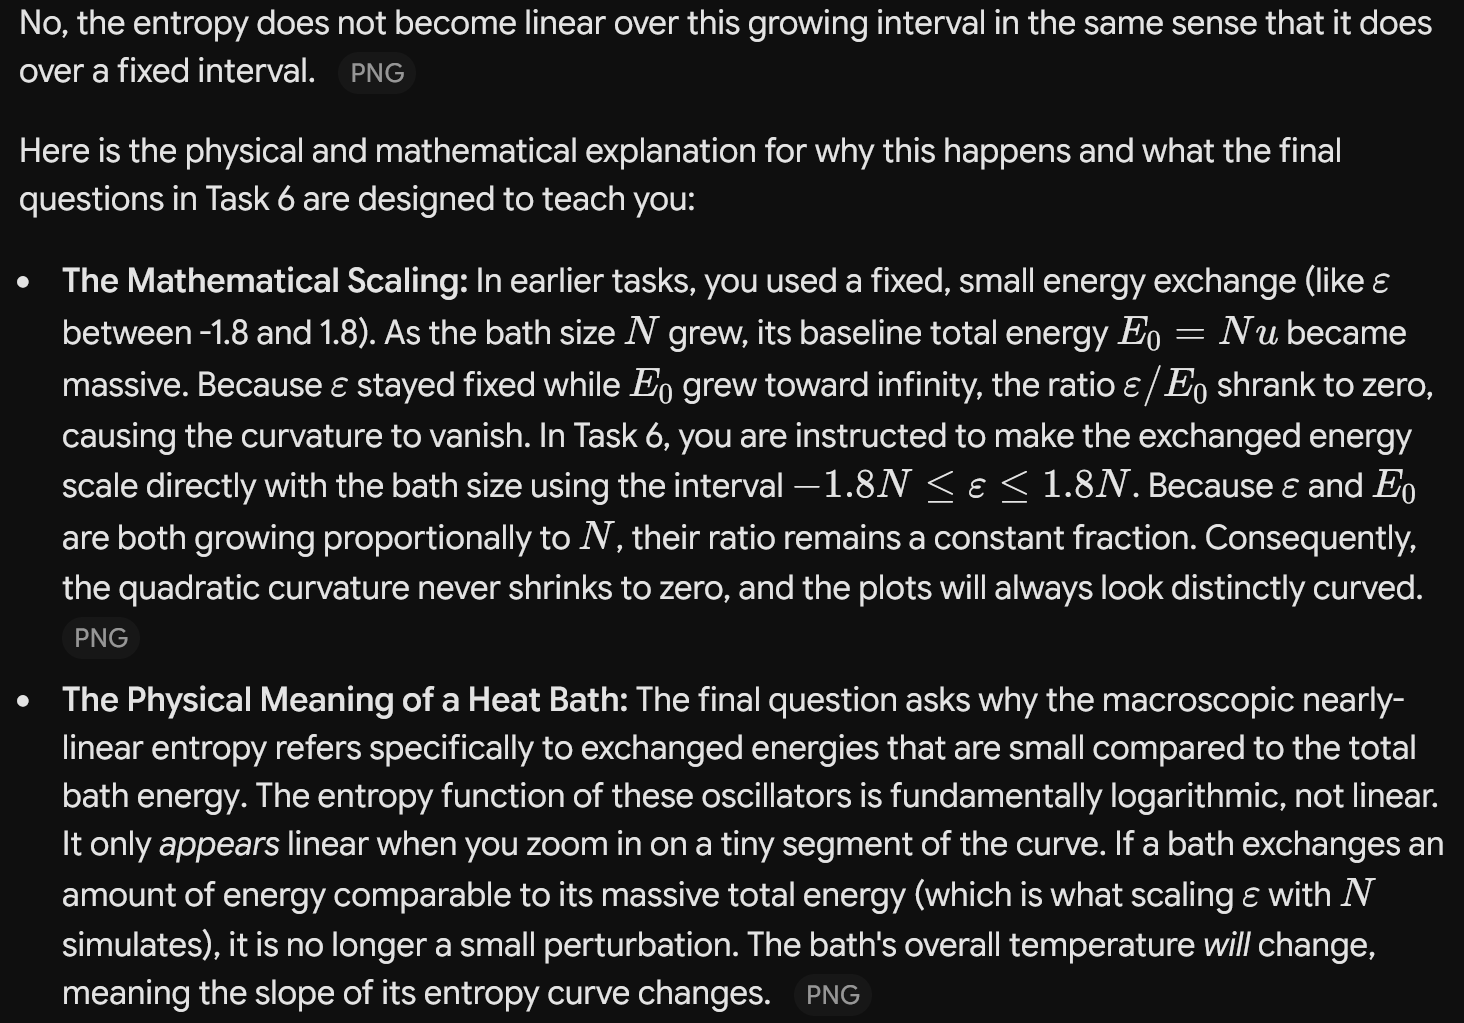